<a href="https://colab.research.google.com/github/brenaSF/RFM-Segmentation/blob/colab-notebook/RFM_Mapeamento_de_Perfil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentação de usuários/habitantes


## 1.Entendimento do Negócio

Resumo do projeto :

- Este projeto utiliza dados públicos da base de dados do IBGE, nomeado "Condições de Vida 2017".

- Objetivo: Realizar o mapeamento de perfis socioeconômicos através das condições de moradia,infraestrutura e padrão de vida

- Contexto : Como o mapeamento de perfis socioeconômicos influenciam na criação de planos de desenvolvimento sustentável?

Passos para o desenvolvimento do projeto :

1. Realizar da Análise Exploratória de Dados
2. Aplicar a Featuring Engeneering para geração de Indíces para avaliação da infraestrutura, vulnerabilidade alimentar e capacidade dos grupos sociais da pesquisa
3. Aplicar modelo de clustering

## 2.Entendimento dos dados

Análise Exploratória (EDA): Principais descobertas, volume de dados, distribuição das variáveis e identificação de dados nulos ou discrepantes.

In [ ]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 7.5 MB/s eta 0:00:00


## Importação de Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Importação da base de dados condicçoes de vida 2017
data = pd.read_csv("br_ibge_pof_condicoes_vida_2017.csv")

In [ ]:
# Visualização dos valores do dataset
data.head(5)

,sigla_uf,situacao,id_estrato,id_unidade_primaria_amostragem,id_domicilio,id_unidade_consumo,id_informante,V61041,V61042,V61043,...,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103,peso,peso_final
0,AC,1,1202,120004720,12000472002,1200047200201,120004720020101,2,2,2,...,NaN,NaN,NaN,NaN,NaN,3,1500,500,140.926331,166.548111
1,AC,1,1202,120004720,12000472003,1200047200301,120004720030101,2,2,2,...,2.0,2.0,2.0,2.0,2.0,4,5000,1500,140.926331,166.548111
2,AC,1,1202,120004720,12000472004,1200047200401,120004720040102,2,1,2,...,NaN,NaN,NaN,NaN,NaN,2,6000,1000,140.926331,166.548111
3,AC,1,1202,120004720,12000472005,1200047200501,120004720050102,1,2,2,...,NaN,NaN,NaN,NaN,NaN,3,1500,900,140.926331,166.548111
4,AC,1,1202,120004720,12000472010,1200047201001,120004720100101,1,1,1,...,NaN,NaN,NaN,NaN,NaN,4,2000,700,140.926331,166.548111


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58039 entries, 0 to 58038
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sigla_uf                        58039 non-null  object 
 1   situacao                        58039 non-null  int64  
 2   id_estrato                      58039 non-null  int64  
 3   id_unidade_primaria_amostragem  58039 non-null  int64  
 4   id_domicilio                    58039 non-null  int64  
 5   id_unidade_consumo              58039 non-null  int64  
 6   id_informante                   58039 non-null  int64  
 7   V61041                          58039 non-null  int64  
 8   V61042                          58039 non-null  int64  
 9   V61043                          58039 non-null  int64  
 10  V61044                          58039 non-null  int64  
 11  V61045                          58039 non-null  int64  
 12  V61046                          

- Ao aplicar .info() foi descoberto variáveis com valores ausentes(V6112 à V6121), as quais estão relacionadas a Insegurança Alimentar do últimos 3 meses da amostra.
>  - Para variáveis que tinham como pré-requisito haver moradores menores de 18 anos, é provável que não haja nenhum integrante menor de idade.
>  - Para variáveis que tinham como pré-requisito haver moradores maiores de 18 anos, é provável que os moradores tenham respondido NÃO para perguntas anteriores, como "Indica se, segundo o informante, nos últimos três meses os alimentos acabaram antes que os moradores do domicílio tivessem dinheiro para comprar mais comida	" ou "Indica se, segundo o informante, nos últimos três meses os moradores do domicílio ficaram sem dinheiro para ter uma alimentação saudável e variada".

In [ ]:
print(data.isnull().sum())

sigla_uf                              0
situacao                              0
id_estrato                            0
id_unidade_primaria_amostragem        1
id_domicilio                          1
id_unidade_consumo                    1
id_informante                         1
V61041                                1
V61042                                1
V61043                                1
V61044                                1
V61045                                1
V61046                                1
V61051                                1
V61052                                1
V61053                                1
V61054                                1
V61055                                1
V61056                                1
V61057                                1
V61058                                1
V61061                                1
V61062                                1
V61063                                1
V61064                                1


Variáveis V6112 à V6115 concentram 27690 valores nulos e variáveis V6116 à V6121 concentram 35802 valores nulos. Desse modo, é necessário realizar tratamento adequado desses valores. A exclusão determinaria a diminuição drástica da base de dados , além de excluir núcleos familiares relevantes para o mapeamento socieconômico.
Dessa forma, uma alternativa é aplicar 0 em todas os espaços vazios.

## EDA

# Classificação das variáveis categóricas

V61041 - padrão de vida da família relação a alimentação

V61042 - do padrão de vida da família em relação a moradia

V61043 - do padrão de vida da família em relação a vestuário

V61044 - do padrão de vida da família em relação ao informante

V61045 - do padrão de vida da família em relação a saúde

V61046 - do padrão de vida da família em relação a lazer

V61051 - condições de moradia da família em relação ao serviço de fornecimento de água


### Retirar rótulos com ID

In [ ]:
data = data.drop('id_estrato',axis =1)
data = data.drop('id_unidade_primaria_amostragem',axis =1)
data = data.drop('id_domicilio',axis =1)
data = data.drop('id_unidade_consumo',axis =1)
data = data.drop('id_informante',axis =1)
data = data.drop('peso',axis =1)
data = data.drop('peso_final',axis =1)

# Renomear nome das variaveis

In [ ]:
# renomear nome das variaveis categoricas

#data['padrao_alimentacao'] = data['V61041']
#data['padrao_moradia'] = data['V61042']
#data['padrao_vestuario'] = data['V61043']
data['padrao_informante'] = data['V61044']
#data['padrao_saude'] = data['V61045']
#data['padrao_lazer'] = data['V61046']


In [ ]:

data = data.drop(columns=['V61044'])
data.columns

Index(['sigla_uf', 'situacao', 'V61051', 'V61052', 'V61053', 'V61054',
       'V61055', 'V61056', 'V61057', 'V61058', 'V61061', 'V61062', 'V61063',
       'V61064', 'V61065', 'V61066', 'V61067', 'V61068', 'V61069', 'V610610',
       'V610611', 'V61071', 'V61072', 'V61073', 'V6108', 'V6109', 'V6110',
       'V6111', 'V6112', 'V6113', 'V6114', 'V6115', 'V6116', 'V6117', 'V6118',
       'V6119', 'V6120', 'V6121', 'V6101', 'V6102', 'V6103',
       'padrao_alimentacao', 'padrao_moradia', 'padrao_vestuario',
       'padrao_saude', 'padrao_lazer', 'padrao_informante'],
      dtype='object')

In [ ]:

data = data.drop(columns=['V61042','V61043','V61045','V61046'])
data.columns

Index(['sigla_uf', 'situacao', 'V61044', 'V61051', 'V61052', 'V61053',
       'V61054', 'V61055', 'V61056', 'V61057', 'V61058', 'V61061', 'V61062',
       'V61063', 'V61064', 'V61065', 'V61066', 'V61067', 'V61068', 'V61069',
       'V610610', 'V610611', 'V61071', 'V61072', 'V61073', 'V6108', 'V6109',
       'V6110', 'V6111', 'V6112', 'V6113', 'V6114', 'V6115', 'V6116', 'V6117',
       'V6118', 'V6119', 'V6120', 'V6121', 'V6101', 'V6102', 'V6103',
       'padrao_alimentacao', 'padrao_moradia', 'padrao_vestuario',
       'padrao_saude', 'padrao_lazer'],
      dtype='object')

### Boxplot com valor mínimo de gastos com alimentação

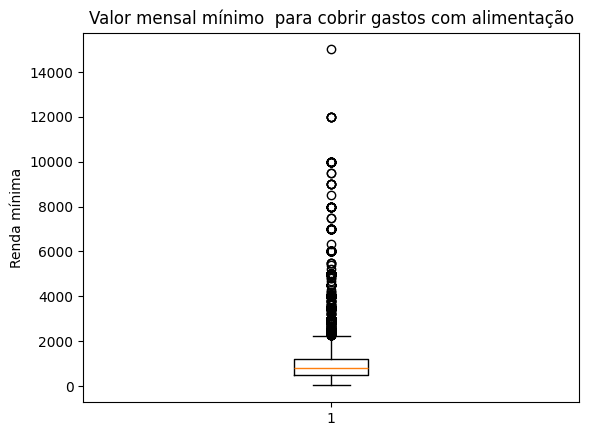

In [ ]:
# gerar boxplot da renda minima
plt.boxplot(data['V6103'])
plt.title("Valor mensal mínimo  para cobrir gastos com alimentação")
plt.ylabel("Renda mínima")
plt.show()

- O gráfico mostra valores discrepantes para o mínimo necessário para alimentação entre as famílias da amostra.

#### Hipóteses criadas a partir da análise do gráfico de boxplot:
- As famílias que informaram o valor mínimo acima de 2000 reais tem maior probabilidade de ter maior Segurança Alimentar - Depende do que é considerado básico para cada família e o tamanho

#### Como prosseguir ?
- Continuar com valores de outliers, pois estes aderem a expectativa de cada família da pesquisa do IBGE.
- Existem famílias que já tem poder aquisitivo alto, e consomem além do básico no mês, o que implica nos casos de 12000 ou 15000 como mínimo para cobrir os gastos na alimentação.
- Criação de variável renda_minima_per_capita

### Correlação de variáveis

In [ ]:
# dataset somente com números
data_num = data.select_dtypes(include=['number'])
data_num.head()

,situacao,V61041,V61042,V61043,V61044,V61045,V61046,V61051,V61052,V61053,...,V6115,V6116,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103
0,1,2,2,2,3,3,3,2,2,2,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,3,1500,500
1,1,2,2,2,2,3,3,3,2,3,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4,5000,1500
2,1,2,1,2,3,3,3,3,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,6000,1000
3,1,1,2,2,1,2,2,2,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1500,900
4,1,1,1,1,2,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2000,700


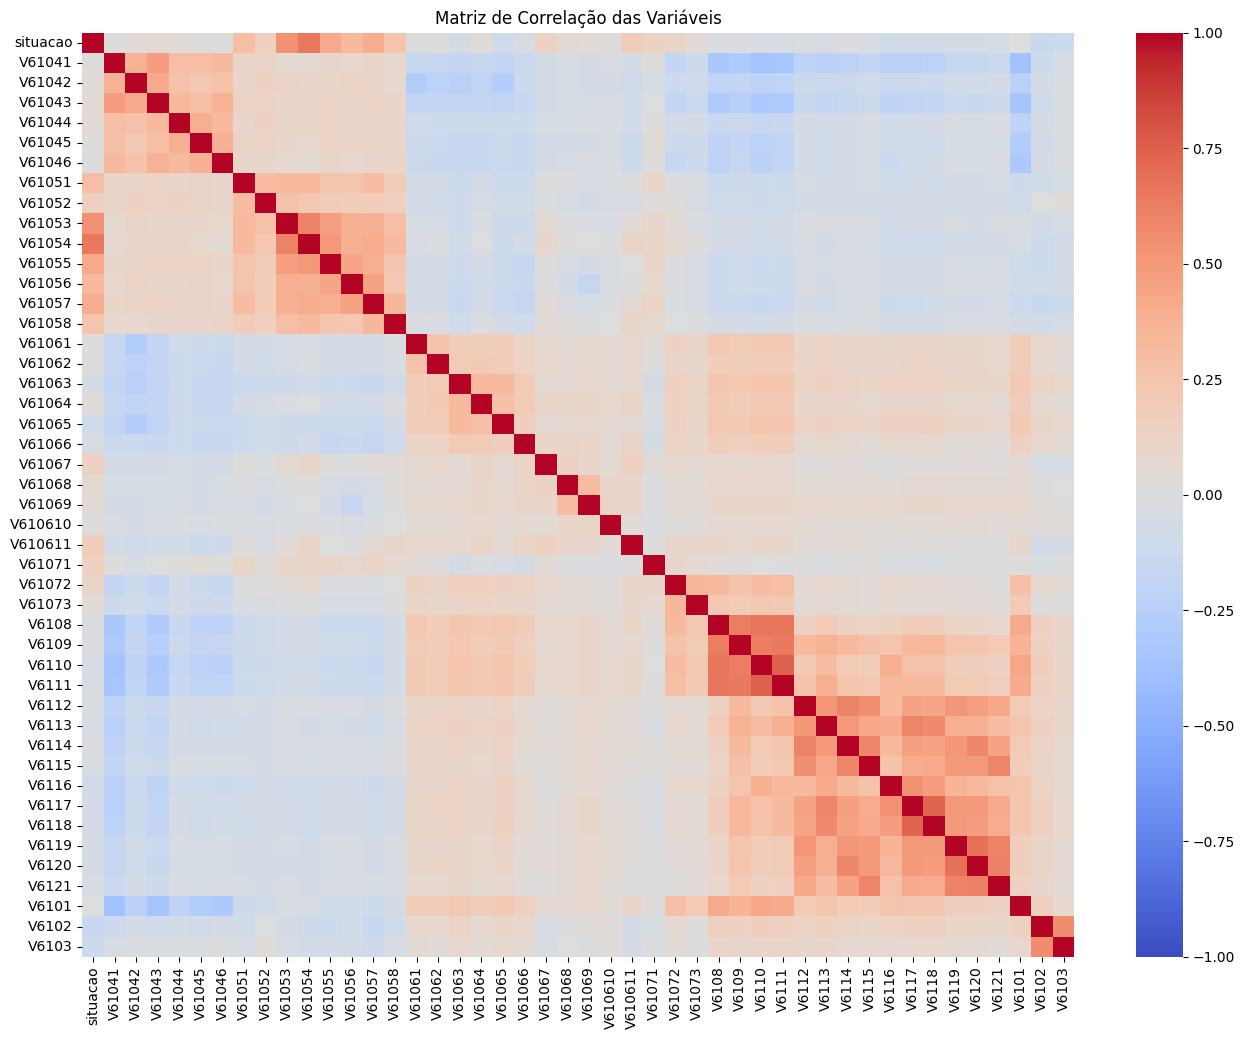

In [ ]:
plt.figure(figsize=(16, 12))
corr = data_num.corr()

# Criar o heatmap
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

### Avaliação do Padrão de Vida

#### Análise do Padrão de Vida com relação a Alimentação


In [ ]:
# 1. Guardar rótulo em variável que será utilizada para pegar indíces e total de vlaore por indíces
padrao_alimentacao = data['V61041'].value_counts()
print(padrao_alimentacao)

V61041
1    33925
2    20827
3     3287
Name: count, dtype: int64


In [ ]:
# 1. Mapear
# 2. Replace com os novos valores
# 3. Guardar atributo em variável para utilização dos indíces e o total de valores por indíces

dict_alimentacao  = {1:"Bom", 2:"Satisfatório", 3:"Ruim"}
print(dict_alimentacao)

data['V61041_rotulo'] = data['V61041'].replace(dict_alimentacao)
data['V61041_rotulo'] = data['V61041_rotulo'].astype('category')

padrao_alimentacao_rotulo = data['V61041_rotulo'].value_counts()
print(padrao_alimentacao_rotulo)

{1: 'Bom', 2: 'Satisfatório', 3: 'Ruim'}
V61041_rotulo
Bom             33925
Satisfatório    20827
Ruim             3287
Name: count, dtype: int64


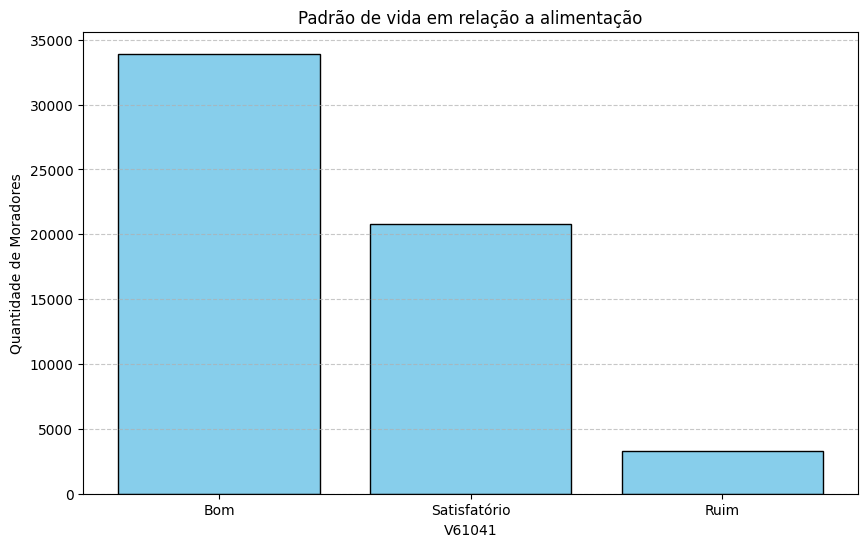

In [ ]:
# 1. Criar gráfico de barrar com barplot (dados categóricos)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(
    x=padrao_alimentacao_rotulo.index.astype(str),
    height=padrao_alimentacao_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("Padrão de vida em relação a alimentação")
plt.xlabel("V61041")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

#### Análise do Padrão de Vida com relação a moradia



In [ ]:
padrao_moradia = data['V61042'].value_counts()
print(padrao_moradia)

V61042
1    38066
2    15616
3     4357
Name: count, dtype: int64


In [ ]:
# 1. Mapear
# 2. Replace com os novos valores
# 3. Guardar atributo em variável para utilização dos indíces e o total de valores por indíces

dict_moradia  = {1:"Bom", 2:"Satisfatório", 3:"Ruim"}
print(dict_moradia)

data['V61042_rotulo'] = data['V61042'].replace(dict_moradia)
data['V61042_rotulo'] = data['V61042_rotulo'].astype('category')

padrao_moradia_rotulo = data['V61042_rotulo'].value_counts()
print(padrao_moradia_rotulo)

{1: 'Bom', 2: 'Satisfatório', 3: 'Ruim'}
V61042_rotulo
Bom             38066
Satisfatório    15616
Ruim             4357
Name: count, dtype: int64


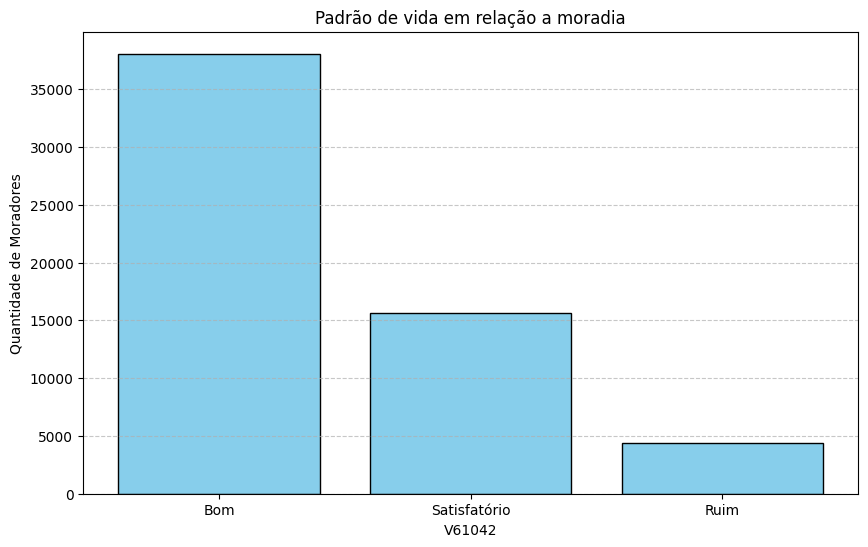

In [ ]:
#Criar gráfico

plt.figure(figsize=(10,6))
plt.title("Padrão de vida em relação a moradia")
plt.bar(
    x=padrao_moradia_rotulo.index.astype(str),
    height=padrao_moradia_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("V61042")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

#### Análise do Padrão de Vida com relação a vestuário



V61043
1    32404
2    21095
3     4540
Name: count, dtype: int64
{1: 'Bom', 2: 'Satisfatório', 3: 'Ruim'}


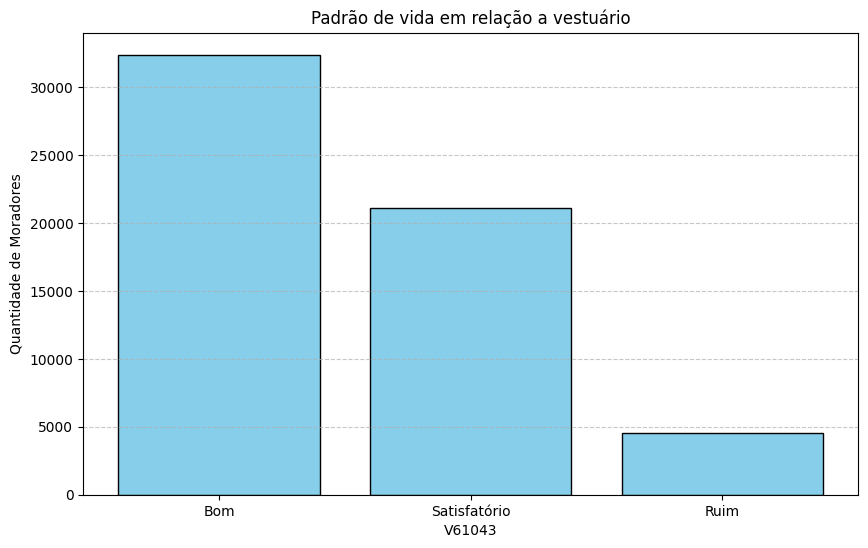

In [ ]:
padrao_vestuario = data['V61043'].value_counts()
print(padrao_vestuario)

# 1. Mapear
# 2. Replace com os novos valores
# 3. Guardar atributo em variável para utilização dos indíces e o total de valores por indíces

dict_moradia  = {1:"Bom", 2:"Satisfatório", 3:"Ruim"}
print(dict_moradia)

data['V61043_rotulo'] = data['V61043'].replace(dict_moradia)
data['V61043_rotulo'] = data['V61043_rotulo'].astype('category')

padrao_vestuario_rotulo = data['V61043_rotulo'].value_counts()

#Criar gráfico

plt.figure(figsize=(10,6))
plt.title("Padrão de vida em relação a vestuário")
plt.bar(
    x=padrao_vestuario_rotulo.index.astype(str),
    height=padrao_vestuario_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("V61043")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

#### Análise do Padrão de Vida com relação ao fornecimento de água


In [ ]:
# 1. Guardar rótulo em variável que será utilizada para pegar indíces e total de vlaore por indíces
padrao_fornecimento_agua = data['V61051'].value_counts()
print(padrao_fornecimento_agua)

V61051
1    37104
2     9061
3     6131
4     5743
Name: count, dtype: int64


In [ ]:
# 1. Mapear
# 2. Replace com novos valores
# 3. Guardar rótulo com o novo mapeamento dos indíces

dict_agua = {1:"Bom", 2:"Satisfatório", 3:"Ruim", 4:"Indisponível"}
print(dict_agua)

data['V61051_rotulo'] = data['V61051'].replace(dict_agua)
data['V61051_rotulo'] = data['V61051_rotulo'].astype('category')

padrao_fornecimento_agua_rotulo = data['V61051_rotulo'].value_counts()
print(padrao_fornecimento_agua_rotulo)

{1: 'Bom', 2: 'Satisfatório', 3: 'Ruim', 4: 'Indisponível'}
V61051_rotulo
Bom             37104
Satisfatório     9061
Ruim             6131
Indisponível     5743
Name: count, dtype: int64


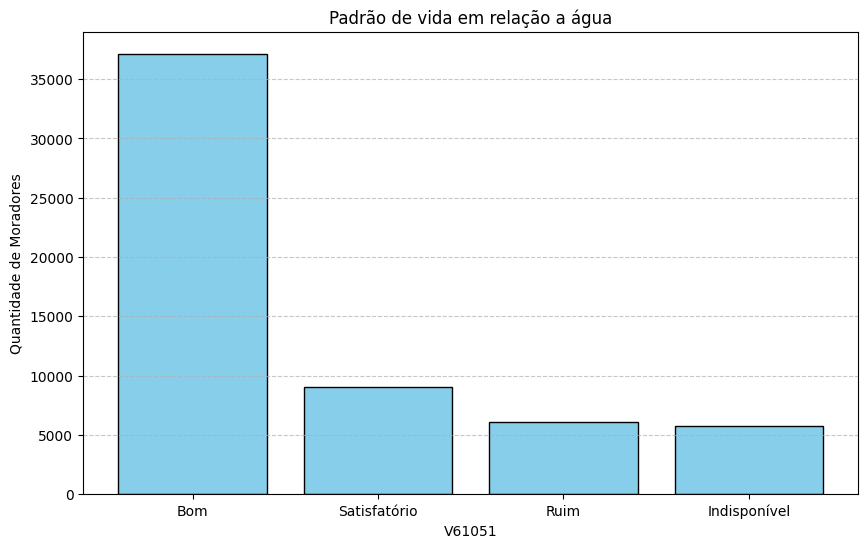

In [ ]:
# Criar gráfico

plt.figure(figsize=(10,6))
plt.bar(
    x=padrao_fornecimento_agua_rotulo.index.astype(str),
    height=padrao_fornecimento_agua_rotulo.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("Padrão de vida em relação a água")
plt.xlabel("V61051")
plt.ylabel("Quantidade de Moradores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Gráfico de barras empilhadas 100%

In [ ]:
print(data.columns)

Index(['sigla_uf', 'situacao', 'V61051', 'V61052', 'V61053', 'V61054',
       'V61055', 'V61056', 'V61057', 'V61058', 'V61061', 'V61062', 'V61063',
       'V61064', 'V61065', 'V61066', 'V61067', 'V61068', 'V61069', 'V610610',
       'V610611', 'V61071', 'V61072', 'V61073', 'V6108', 'V6109', 'V6110',
       'V6111', 'V6112', 'V6113', 'V6114', 'V6115', 'V6116', 'V6117', 'V6118',
       'V6119', 'V6120', 'V6121', 'V6101', 'V6102', 'V6103',
       'padrao_alimentacao', 'padrao_moradia', 'padrao_vestuario',
       'padrao_saude', 'padrao_lazer', 'padrao_informante'],
      dtype='object')


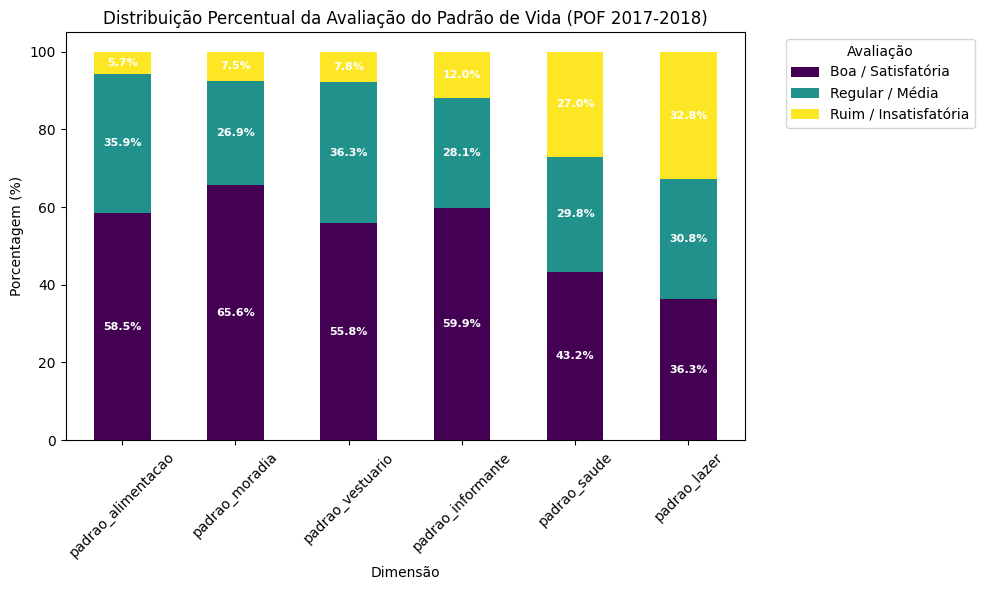

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



data = pd.read_csv('br_ibge_pof_condicoes_vida_2017.csv')

# 1 - ajustar nome das variáveis
conjunto = {
    'V61041': 'padrao_alimentacao',
    'V61042': 'padrao_moradia',
    'V61043': 'padrao_vestuario',
    'V61044': 'padrao_informante',
    'V61045': 'padrao_saude',
    'V61046': 'padrao_lazer',
}

# 2 - renomear variáveis
df_novo = data.rename(columns=conjunto)

colunas_interesse = list(conjunto.values())

# 3 - renomear rótulos
rotulos_respostas = {
    1: 'Boa / Satisfatória',
    2: 'Regular / Média',
    3: 'Ruim / Insatisfatória',
    4: 'Não Possui / Péssima'
}

for col in colunas_interesse:
    df_novo[col] = df_novo[col].map(rotulos_respostas)

# 4 - criar dataframe so com variaveis de interesse
df_novo = df_novo[colunas_interesse]

# 5 - transformar valores para cada variável em porcentagem
df_porcentagem = (
    df_novo.apply(lambda col: col.value_counts(normalize=True,sort=False) * 100)
    .T
)


# 6 - plotar

ax = df_porcentagem.plot(
    kind='bar', stacked=True, colormap='viridis', figsize=(10, 6)
)

for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container,labels=labels,label_type='center',color='white',fontsize=8,fontweight ='bold')

plt.title('Distribuição Percentual da Avaliação do Padrão de Vida (POF 2017-2018)')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Dimensão')
plt.legend(title='Avaliação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




- Segundo o gráfico de percentual de padrão de vida, há cerca de 58,5%  dos entrevistados possuem um padrão de alimentação, entretanto, 35,9% informaram que o padrão de alimentação é regualr e 5,7% informaram que o padrão de alimentação é ruim. Assim, somando-se os dois últimos grupos, há 41,6% da amostra que possui algum tipo de vulnerabilidade alimentar.

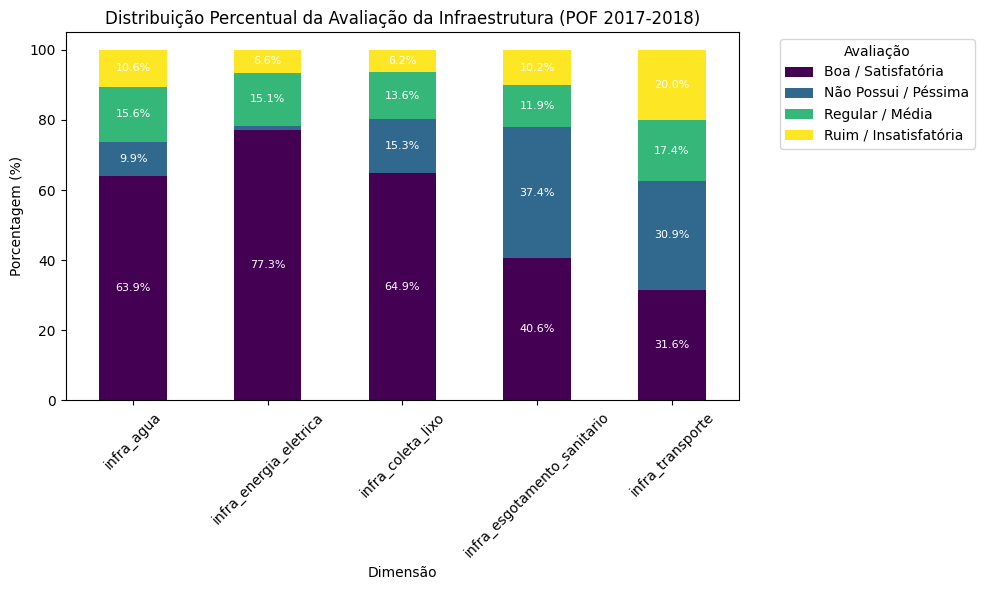

In [ ]:
conjunto_infraestrutura = {
    'V61051': 'infra_agua' ,
    'V61052':'infra_energia_eletrica' ,
    'V61054': 'infra_coleta_lixo' ,
    'V61057': 'infra_esgotamento_sanitario'  ,
    'V61058':'infra_transporte'
}

rotulos_respostas = {
    1: 'Boa / Satisfatória',
    2: 'Regular / Média',
    3: 'Ruim / Insatisfatória',
    4: 'Não Possui / Péssima'
}

conjunto_interesse_infraestrutura = list(conjunto_infraestrutura.values())

df_novo_infra = data.rename(columns=conjunto_infraestrutura)

df_novo_infra= df_novo_infra[conjunto_interesse_infraestrutura]

df_novo_infra.head()


df_novo_infra = df_novo_infra.apply(lambda col: col.map(rotulos_respostas))

df_novo_infra.head()

df_porcentagem = df_novo_infra.apply(lambda col: col.value_counts(normalize=True,sort=False) * 100).T

ax = df_porcentagem.plot(kind = 'bar', figsize=(10,6), colormap = 'viridis', stacked = True )

for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container,labels=labels,label_type='center',color='white',fontsize=8)

plt.title('Distribuição Percentual da Avaliação da Infraestrutura (POF 2017-2018)')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Dimensão')

plt.legend(title='Avaliação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- Infraestrutura - Água :  Cerca de 63,9% dos entrevistados informaram ter um bom serviço de fornecimento de água em sua residência. E 20,5%  informaram ter infraestrutura insuficiente.
- Infraestrutura - Energia Elétrica :
- Próximo passo : Realizar cruzamento de dados para saber em quais regiões existem melhor ou pior qualidade de infraestrutura
Verificar a correlação entre a infraestrutura e a renda media

"Os dados sobre o padrão de vida revelam que mais da metade dos entrevistados (58,5%) desfruta de uma boa alimentação em suas residências. Por outro lado, o gráfico também acende um alerta: uma parcela expressiva de 35,9% classifica sua situação como regular, enquanto 5,7% vivem em condições insatisfatórias. Somados, esses dois grupos representam 41,6% da amostra, evidenciando que quase metade da população avaliada enfrenta algum nível de vulnerabilidade ou restrição alimentar."


# Análise de padrão de vida em relação a alimentação por região

In [ ]:

df_novo['sigla_uf'] = data['sigla_uf']

df_novo.columns


Index(['padrao_alimentacao', 'padrao_moradia', 'padrao_vestuario',
       'padrao_informante', 'padrao_saude', 'padrao_lazer', 'sigla_uf'],
      dtype='object')

In [ ]:
# 1 - verificar  quais regioes coincidem com os padroes de vida de alimentacao - bom-regular-pessimo

grupo_alimentacao_regiao = df_novo.groupby('sigla_uf')['padrao_alimentacao'].sum().reset_index()

# 2 - verificar a frequencia por regiao

grupo_alimentacao_regiao = grupo_alimentacao_regiao.sort_values(by='padrao_alimentacao', ascending=False)

grupo_alimentacao_regiao

,sigla_uf,padrao_alimentacao
4,BA,Ruim / InsatisfatóriaRegular / MédiaBoa / Sati...
15,PE,Regular / MédiaRuim / InsatisfatóriaBoa / Sati...
0,AC,Regular / MédiaRegular / MédiaRegular / MédiaB...
9,MA,Regular / MédiaRegular / MédiaBoa / Satisfatór...
16,PI,Regular / MédiaRegular / MédiaBoa / Satisfatór...
10,MG,Regular / MédiaBoa / SatisfatóriaRegular / Méd...
12,MT,Regular / MédiaBoa / SatisfatóriaRegular / Méd...
6,DF,Regular / MédiaBoa / SatisfatóriaBoa / Satisfa...
2,AM,Regular / MédiaBoa / SatisfatóriaBoa / Satisfa...
5,CE,Regular / MédiaBoa / SatisfatóriaBoa / Satisfa...


In [ ]:
# 1. Contagem absoluta por estado e padrão de alimentação
frequencia_alimentacao = pd.crosstab(
    df_novo['sigla_uf'],
    df_novo['padrao_alimentacao'],
    margins=True,
    margins_name='Total'
)

# 2. Porcentagem por estado (frequência relativa na linha)
proporcao_alimentacao = pd.crosstab(
    df_novo['sigla_uf'],
    df_novo['padrao_alimentacao'],
    normalize='index'
) * 100

print(proporcao_alimentacao.round(1))


# criar dataframe com proporcao padrao alimentacao
df_proporcao_alimentacao = pd.DataFrame(proporcao_alimentacao)

df_proporcao_alimentacao.head()

padrao_alimentacao  Boa / Satisfatória  Regular / Média  Ruim / Insatisfatória
sigla_uf                                                                      
AC                                54.4             37.2                    8.4
AL                                47.5             45.3                    7.2
AM                                57.7             34.3                    8.0
AP                                54.3             39.3                    6.4
BA                                48.4             43.4                    8.3
CE                                52.8             40.5                    6.7
DF                                64.0             31.1                    5.0
ES                                64.4             31.4                    4.2
GO                                60.0             35.2                    4.9
MA                                45.6             45.6                    8.8
MG                                60.9             3

padrao_alimentacao,Boa / Satisfatória,Regular / Média,Ruim / Insatisfatória
sigla_uf,,,
AC,54.411765,37.184874,8.403361
AL,47.494305,45.273349,7.232346
AM,57.709012,34.310532,7.980456
AP,54.319372,39.267016,6.413613
BA,48.370607,43.354633,8.274760


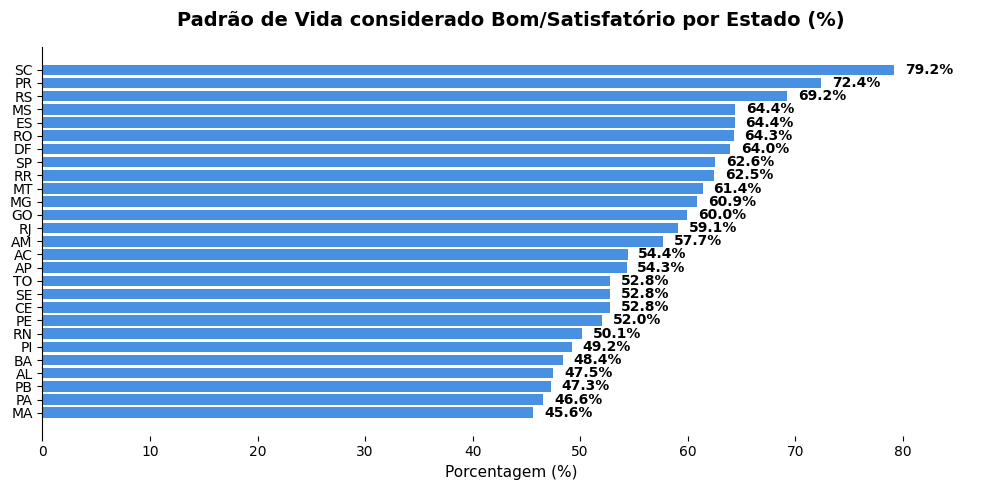

In [ ]:

if 'sigla_uf' not in df_proporcao_alimentacao.columns and df_proporcao_alimentacao.index.name == 'sigla_uf':
    df_proporcao_alimentacao = df_proporcao_alimentacao.reset_index()
df_proporcao_alimentacao.columns = df_proporcao_alimentacao.columns.str.strip()



df_proporcao_alimentacao = df_proporcao_alimentacao.sort_values(by='Boa / Satisfatória', ascending=True)

plt.figure(figsize=(10, 5))

barras = plt.barh(df_proporcao_alimentacao['sigla_uf'], df_proporcao_alimentacao['Boa / Satisfatória'], color='#4a90e2')

for barra in barras:
    largura = barra.get_width()
    plt.text(largura + 1,
             barra.get_y() + barra.get_height()/2,
             f'{largura:.1f}%',
             va='center', ha='left', fontsize=10, fontweight='bold')


# 6. Ajustes de layout e títulos
plt.xlabel('Porcentagem (%)', fontsize=11)
plt.title('Padrão de Vida considerado Bom/Satisfatório por Estado (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, max(df_proporcao_alimentacao['Boa / Satisfatória']) + 8)

# Remove as bordas desnecessárias do gráfico para um visual mais limpo
for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

- O gráfico revela que São Paulo é o Estado em que 79.2% entrevistados informaram ter padrão de vida da família em relação a Alimentação, considerado Bom/Satisfatório, assim, o que tem o maoir percentual de famílias com boa qualidade de alimentaçã0. Já o estado do Maranhão  possui a menor quantidade de entrevistado que apontaram ter um padrao de  vida em relaçao a alimentação considerado Bom/Satis

### Análise de Correspondência Múltipla

Coordenadas das Categorias:
                  0         1
V61041__1 -0.522920  0.138442
V61041__2  0.668507 -0.262738
V61041__3  1.161262  0.235901
V61042__1 -0.430492  0.112560
V61042__2  0.748227 -0.368894

Variância explicada por dimensão:
[11.55313128  8.32909273]


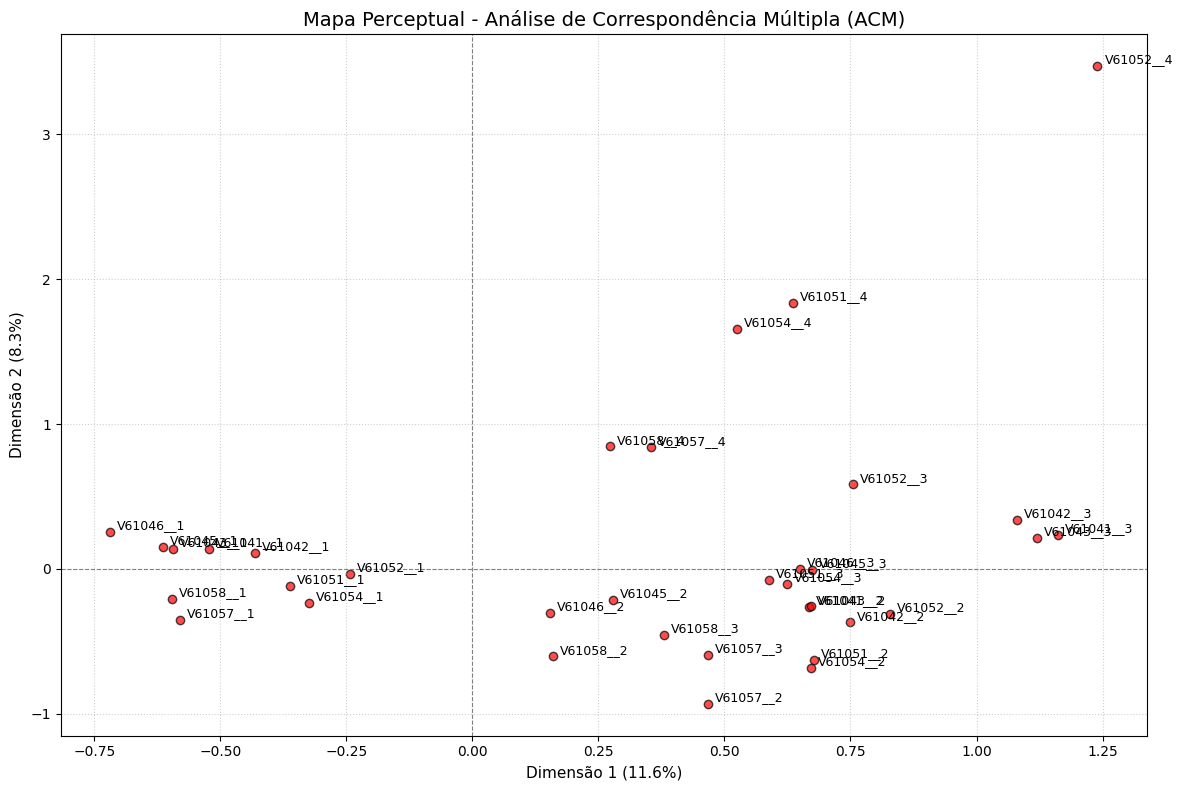

In [ ]:
import pandas as pd
import prince
import matplotlib.pyplot as plt

# 1. Carregar o arquivo
data = pd.read_csv("br_ibge_pof_condicoes_vida_2017.csv")

# 2. Selecionar apenas as variáveis de interesse
colunas_interesse = [
    'V61041', 'V61042', 'V61043', 'V61045', 'V61046', # Padrão de Vida
    'V61051', 'V61052', 'V61054', 'V61057', 'V61058'  # Infraestrutura
]

# Filtrar o DataFrame e tratar valores nulos (se houver)
df_mca = data[colunas_interesse].dropna().copy()

# 3. Converter todos os números em texto (string) para serem tratados como categorias
df_mca = df_mca.astype(str)

#alterar o nome das variáveis

df_mca.rename(columns={
    'V61041' : 'padrao_alimentacao',
    'V61042' : 'padrao_moradia',
    'V61043' : 'padrao_vestuario',
    'V61045' : 'padrao_saude',
    'V61046' : 'padrao_lazer',
    'V61051' : 'infra_agua',
    'V61052' : 'infra_energia',
    'V61054' : 'infra_coleta_lixo',
    'V61057' : 'infra_esgotamento_sanitario',
    'V61058' : 'infra_transporte'

}
       )


# 4. Inicializar e aplicar o modelo de ACM (MCA)
# n_components=2 ajusta o modelo para 2 dimensões no gráfico
mca = prince.MCA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(df_mca)

# 5. Obter as coordenadas das variáveis (categorias de resposta)
var_coordinates = mca.column_coordinates(df_mca)
print("Coordenadas das Categorias:")
print(var_coordinates.head())

# 6. Obter o percentual de variância explicada por cada dimensão
print("\nVariância explicada por dimensão:")
print(mca.percentage_of_variance_)
# 7. Gerar o Mapa Perceptual usando Matplotlib diretamente
coords = mca.column_coordinates(df_mca)

plt.figure(figsize=(12, 8))

# Plota os pontos das categorias
plt.scatter(coords[0], coords[1], color='red', alpha=0.7, edgecolors='k')

# Adiciona os rótulos de cada categoria
for idx, row in coords.iterrows():
    plt.annotate(
        idx,
        (row[0], row[1]),
        xytext=(5, 2),
        textcoords='offset points',
        fontsize=9
    )

# Linhas de referência no centro (0, 0)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Títulos e eixos
var_1 = mca.percentage_of_variance_[0]
var_2 = mca.percentage_of_variance_[1]

plt.title("Mapa Perceptual - Análise de Correspondência Múltipla (ACM)", fontsize=14)
plt.xlabel(f"Dimensão 1 ({var_1:.1f}%)", fontsize=11)
plt.ylabel(f"Dimensão 2 ({var_2:.1f}%)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 3.Preparação dos dados

- Seleção de variáveis
- Limpeza
- Engenharia de recursos (Feature Engineering)
- Criação dos índices sintéticos.

In [ ]:
data.describe()

,situacao,id_estrato,id_unidade_primaria_amostragem,id_domicilio,id_unidade_consumo,id_informante,V61041,V61042,V61043,V61044,...,V6117,V6118,V6119,V6120,V6121,V6101,V6102,V6103,peso,peso_final
count,47435.000000,47435.000000,4.743400e+04,4.743400e+04,4.743400e+04,4.743400e+04,47434.000000,47434.000000,47434.000000,47434.000000,...,11633.000000,11633.000000,11633.000000,11633.000000,11633.000000,47434.000000,47434.000000,47434.000000,47434.000000,47434.000000
mean,1.243238,3099.629177,3.088702e+08,3.088702e+10,3.088702e+12,3.088702e+14,1.480879,1.425412,1.526163,1.524118,...,1.733087,1.721740,1.882661,1.893836,1.927534,2.928047,3383.444597,959.381246,792.327016,962.330355
std,0.429042,1208.909685,1.207290e+08,1.207290e+10,1.207290e+12,1.207290e+14,0.604154,0.631345,0.638342,0.700613,...,0.442366,0.448161,0.321837,0.308060,0.259270,1.226928,3861.539401,713.249506,727.746751,861.595193
min,1.000000,1101.000000,1.100000e+08,1.100000e+10,1.100000e+12,1.100000e+14,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80.000000,50.000000,16.104575,23.170091
25%,1.000000,2304.000000,2.300209e+08,2.300209e+10,2.300209e+12,2.300209e+14,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1500.000000,500.000000,360.398843,458.771258
50%,1.000000,2917.000000,2.901159e+08,2.901159e+10,2.901159e+12,2.901159e+14,1.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2500.000000,800.000000,597.026154,735.517781
75%,1.000000,4132.000000,4.101527e+08,4.101527e+10,4.101527e+12,4.101527e+14,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,4000.000000,1000.000000,1056.688137,1284.489972
max,2.000000,5308.000000,5.300442e+08,5.300442e+10,5.300442e+12,5.300442e+14,3.000000,3.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,6.000000,400000.000000,15000.000000,49579.041703,65991.328810


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58039 entries, 0 to 58038
Data columns (total 47 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sigla_uf  58039 non-null  object 
 1   situacao  58039 non-null  int64  
 2   V61041    58039 non-null  int64  
 3   V61042    58039 non-null  int64  
 4   V61043    58039 non-null  int64  
 5   V61044    58039 non-null  int64  
 6   V61045    58039 non-null  int64  
 7   V61046    58039 non-null  int64  
 8   V61051    58039 non-null  int64  
 9   V61052    58039 non-null  int64  
 10  V61053    58039 non-null  int64  
 11  V61054    58039 non-null  int64  
 12  V61055    58039 non-null  int64  
 13  V61056    58039 non-null  int64  
 14  V61057    58039 non-null  int64  
 15  V61058    58039 non-null  int64  
 16  V61061    58039 non-null  int64  
 17  V61062    58039 non-null  int64  
 18  V61063    58039 non-null  int64  
 19  V61064    58039 non-null  int64  
 20  V61065    58039 non-null  in

In [ ]:
print(data.isnull().sum())

sigla_uf        0
situacao        0
V61041          0
V61042          0
V61043          0
V61044          0
V61045          0
V61046          0
V61051          0
V61052          0
V61053          0
V61054          0
V61055          0
V61056          0
V61057          0
V61058          0
V61061          0
V61062          0
V61063          0
V61064          0
V61065          0
V61066          0
V61067          0
V61068          0
V61069          0
V610610         0
V610611         0
V61071          0
V61072          0
V61073          0
V6108           0
V6109           0
V6110           0
V6111           0
V6112       34766
V6113       34766
V6114       34766
V6115       34766
V6116       44512
V6117       44512
V6118       44512
V6119       44512
V6120       44512
V6121       44512
V6101           0
V6102           0
V6103           0
dtype: int64


In [ ]:
linha_maximo_valor_alimentacao = data[data['V6103'] >= 10000]
print(linha_maximo_valor_alimentacao.head(10))

      sigla_uf  situacao  V61041  V61042  V61043  V61044  V61045  V61046  \
2886        AP         1       1       1       2       1       2       1   
4808        AM         1       1       1       1       1       1       2   
7160        BA         1       1       1       1       1       1       1   
7695        BA         1       1       2       1       1       2       2   
13304       DF         1       1       1       2       2       3       3   
16844       MG         1       1       1       1       1       1       3   
17630       MG         1       1       1       1       1       2       2   
19706       MG         1       1       3       1       2       1       1   
25127       MT         1       1       1       1       1       1       1   
28240       MS         1       2       2       2       2       2       3   

       V61051  V61052  ...  V6115  V6116  V6117  V6118  V6119  V6120  V6121  \
2886        2       1  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
4808 

### Seleção de variáveis

In [ ]:
# 3.1. Tratamento de Nulos
df_clean = data.fillna(0)

# 3.2. Função para conversão binária (Presença do problema = 1, Ausência = 0)
def binario(coluna):
    return np.where(coluna == 1, 1, 0)

# 3.3. Engenharia de Recursos (Criação dos Índices Sintéticos)
df_clean['IA_Score'] = (
    binario(df_clean['V6108']) + binario(df_clean['V6109']) +
    binario(df_clean['V6110']) + binario(df_clean['V6112']) +
    binario(df_clean['V6114']) + binario(df_clean['V6119'])
)

df_clean['Habitacao_Score'] = (
    binario(df_clean['V61061']) + binario(df_clean['V61063']) +
    binario(df_clean['V61064']) + binario(df_clean['V61065']) +
    binario(df_clean['V61068']) + binario(df_clean['V61069'])
)

df_clean['Financeiro_Score'] = (
    binario(df_clean['V61071']) + binario(df_clean['V61072']) +
    binario(df_clean['V61073'])
)

### Tratamento de valores nulos

In [ ]:
df_clean.isnull().sum()

,0
sigla_uf,0
situacao,0
V61041,0
V61042,0
V61043,0
V61044,0
V61045,0
V61046,0
V61051,0
V61052,0


In [ ]:
df_clean.head()

,sigla_uf,situacao,V61041,V61042,V61043,V61044,V61045,V61046,V61051,V61052,...,V6118,V6119,V6120,V6121,V6101,V6102,V6103,IA_Score,Habitacao_Score,Financeiro_Score
0,AC,1,2.0,2.0,2.0,3.0,3.0,3.0,2.0,2.0,...,0.0,0.0,0.0,0.0,3.0,1500.0,500.0,1,1,0
1,AC,1,2.0,2.0,2.0,2.0,3.0,3.0,3.0,2.0,...,2.0,2.0,2.0,2.0,4.0,5000.0,1500.0,0,1,0
2,AC,1,2.0,1.0,2.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,2.0,6000.0,1000.0,0,3,2
3,AC,1,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,3.0,1500.0,900.0,0,1,1
4,AC,1,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,4.0,2000.0,700.0,0,1,0


### Tratamento de Outliers

In [ ]:
sns.pairplot(data, kind="scatter", plot_kws={'alpha':0.4})


In [ ]:
data.describe()

#4.Modelagem

#5.Avaliação

In [7]:
%cd '/content/drive/MyDrive/Colab Notebooks'


/content/drive/MyDrive/Colab Notebooks


In [8]:
!git status


fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
